In [1]:
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions3D import getModel, kCrossVal, transfBestparam, import_data
from time import perf_counter
import pandas
import pickle
import os

seed = 7
np.random.seed(seed)

c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [10]:
########################     PREPARATION      ##########################
# introduction of the data
file_path_LF = os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_LF_46_d75.mat")
#file_path_LF = "..\..\Diffusion\DATA\reaction_diffusion_LF_46_d75.mat"
(reaction_LF_test, U_LF_test, x_LF_test) = import_data(file_path_LF)
file_path_HF = os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_HF.mat")
(reaction_HF_test, U_HF_test, x_HF_test) = import_data(file_path_HF)

MemoryError: Unable to allocate 2.98 GiB for an array with shape (50, 801, 100, 100) and data type float64

In [4]:
#plt.figure()
#plt.plot(reaction_LF_test, U_LF_test[
#    :,
#     - 1,
#    12,12
#], "ro", linewidth=1.5, label="LF model")
#plt.plot(
#    reaction_HF_test,
#    U_HF_test[
#    :,
#     - 1,
#    44,44
#],
#    "b*",
#    markersize=7,
#    label="HF model",
#)
#plt.legend(prop={"size": 8.3})
#plt.show()

In [5]:
########################     NORMALIZATION  #########################
# Input
#reaction_LF_test = np.column_stack((reaction_LF_test, x_LF_test))
#reaction_HF_test = np.column_stack((reaction_HF_test, x_HF_test))


reaction_max = np.max(reaction_LF_test)
reaction_min = np.min(reaction_LF_test)

# reaction_test_norm = (reaction_test - reaction_min) / (reaction_max - reaction_min)
reaction_LF_test = (reaction_LF_test - reaction_min) / (
    reaction_max - reaction_min
)
reaction_HF_test = (reaction_HF_test - reaction_min) / (
    reaction_max - reaction_min
)


NameError: name 'reaction_LF_test' is not defined

In [ ]:
#########################     TRAIN SET      ##########################
NepoLF = 5000  # number of epochs for first NN: NN_LF
NepoHF = 3000  # number of epochs for second NN: NN_HF

permutation1 = np.random.permutation(len(reaction_LF_test))
permutation2 = np.random.permutation(len(x_LF_test))
Nlf = 30
reaction_LF = reaction_LF_test[permutation1][0:Nlf]
x_LF = x_LF_test[permutation2][0:Nlf]

reaction_LF = np.column_stack((reaction_LF, x_LF))
reaction_LF_test = np.column_stack((np.repeat(reaction_LF_test, len(x_LF_test)), np.tile(x_LF_test, len(reaction_LF_test))))


# ADD NOISE
# noise_stddev = np.mean(reaction_LF) * 0.025
# noise = np.random.normal(0, noise_stddev, len(reaction_LF))
# reaction_LF = reaction_LF + noise

In [ ]:
U_LF_test = U_LF_test[
    :,
     - 1,
    :,12
]

# TRANSFORMATION
U_t_max_test = np.max(U_LF_test)
U_t_min_test = np.min(U_LF_test)

U_LF_test = (U_LF_test - U_t_min_test) / (U_t_max_test - U_t_min_test)
#U_HF = (U_HF - U_h_min_test) / (U_h_max_test - U_h_min_test)
U_LF = U_LF_test[permutation1,permutation2][0:Nlf,0:Nlf]

permutation1 = np.random.permutation(len(reaction_HF_test))
permutation2 = np.random.permutation(len(x_HF_test))
n_HF = 15
reaction_HF = reaction_HF_test[permutation1][0:n_HF]
x_HF = x_HF_test[permutation2][0:n_HF]
reaction_HF = np.column_stack((reaction_HF, x_HF))
U_HF_test = U_HF_test[:, -1, :,44]
reaction_HF_test = np.column_stack((np.repeat(reaction_HF_test, len(x_HF_test)), np.tile(x_HF_test, len(reaction_HF_test))))

# TRANSFORMATION
U_h_max_test = np.max(U_HF_test)
U_h_min_test = np.min(U_HF_test)
#U_HF = (U_HF - U_h_min_test) / (U_h_max_test - U_h_min_test)
U_HF_test = (U_HF_test - U_h_min_test) / (U_h_max_test - U_h_min_test)

U_HF = U_HF_test[permutation1,permutation2][0:n_HF,0:n_HF]

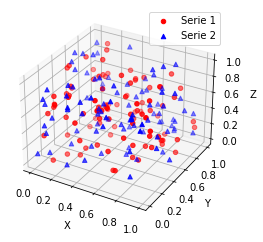

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Genera dati di esempio
np.random.seed(42)
n_points = 100
x1 = np.random.rand(n_points)
y1 = np.random.rand(n_points)
z1 = np.random.rand(n_points)

x2 = np.random.rand(n_points)
y2 = np.random.rand(n_points)
z2 = np.random.rand(n_points)

# Crea un grafico 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Disegna i grafici di dispersione 3D e ottieni i Path3DCollection
scatter1 = ax.scatter(x1, y1, z1, c='r', marker='o', label='Serie 1')
scatter2 = ax.scatter(x2, y2, z2, c='b', marker='^', label='Serie 2')

# Crea la legenda utilizzando i Path3DCollection
ax.legend(handles=[scatter1, scatter2])

# Aggiungi etichette agli assi
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Mostra il grafico
plt.show()
